# Upper envelope comparison (period 2)

This notebook compares the new `upper_jorg_drued` upper-envelope routine against `fues_jax` on the period-2 fixture data.

It produces plots for:
- *Raw (uncleaned) EGM correspondence* (`pol2.csv`, `val2.csv`)
- `fues_jax` refined outputs
- `upper_jorg_drued` outputs evaluated on a user-chosen `m_grid`

Notes:
- `upper_jorg_drued` interpolates only between adjacent input pairs as given (no sorting, no explicit intersection handling).
- `fues_jax` explicitly handles intersections and can produce duplicated `m` points.


In [1]:
import numpy as np
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt

import upper_envelope as upenv

jax.config.update("jax_enable_x64", True)
plt.rcParams["figure.dpi"] = 140

In [2]:
# Load period-2 fixtures
resource_dir = "../../tests/resources/upper_envelope_period_tests"
policy_egm = np.genfromtxt(f"{resource_dir}/pol2.csv", delimiter=",", dtype=float)
value_egm = np.genfromtxt(f"{resource_dir}/val2.csv", delimiter=",", dtype=float)

endog_grid_raw = policy_egm[0, 1:]
policy_raw = policy_egm[1, 1:]
value_raw = value_egm[1, 1:]
expected_value_zero_savings = float(value_egm[1, 0])

print("raw sizes", endog_grid_raw.shape, policy_raw.shape, value_raw.shape)
print("expected_value_zero_savings", expected_value_zero_savings)

raw sizes (500,) (500,) (500,)
expected_value_zero_savings 7.264440456424788


In [3]:
# Value function used in tests
params = {"beta": 0.95, "rho": 1.95, "delta": 0.35}
choice = 0


def utility_crra(consumption, choice, params):
    utility_consumption = (consumption ** (1 - params["rho"]) - 1) / (1 - params["rho"])
    return utility_consumption - (1 - choice) * params["delta"]


def value_func(consumption, choice, params):
    # Mirrors existing tests: value_func already includes continuation value.
    return (
        utility_crra(consumption, choice, params)
        + params["beta"] * expected_value_zero_savings
    )

In [4]:
# Pick a common grid for Druedahl
m_min = float(np.min(endog_grid_raw))
m_max = float(np.max(endog_grid_raw))
m_grid = np.linspace(m_min, m_max, 500)
print("m_grid range", m_grid[0], m_grid[-1], "len", len(m_grid))

m_grid range 4.5853531853973 54.19539854760825 len 500


In [5]:
# Run new upper envelope
endog_out, policy_out, value_out = upenv.drued_jorg_jax(
    endog_grid=jnp.asarray(endog_grid_raw),
    policy=jnp.asarray(policy_raw),
    value=jnp.asarray(value_raw),
    m_grid=jnp.asarray(m_grid),
    expected_value_zero_savings=expected_value_zero_savings,
    value_function=value_func,
    value_function_args=(choice, params),
)

endog_out = np.asarray(endog_out)
policy_out = np.asarray(policy_out)
value_out = np.asarray(value_out)

print("output lens", len(endog_out), len(policy_out), len(value_out))
print("index 0 convention", endog_out[0], policy_out[0], value_out[0])

output lens 501 501 501
index 0 convention 0.0 0.0 7.264440456424788


In [6]:
# Run fues_jax reference
ref_m, ref_c, ref_v = upenv.fues_jax(
    endog_grid=jnp.asarray(endog_grid_raw),
    policy=jnp.asarray(policy_raw),
    value=jnp.asarray(value_raw),
    expected_value_zero_savings=expected_value_zero_savings,
    value_function=value_func,
    value_function_args=(choice, params),
    n_constrained_points_to_add=len(endog_grid_raw) // 10,
)

ref_m = np.asarray(ref_m)
ref_c = np.asarray(ref_c)
ref_v = np.asarray(ref_v)
mask = ~np.isnan(ref_m)
ref_m, ref_c, ref_v = ref_m[mask], ref_c[mask], ref_v[mask]

print("ref lens", len(ref_m), len(ref_c), len(ref_v))
print("ref m has duplicates:", np.any(np.diff(ref_m) == 0))

ref lens 503 503 503
ref m has duplicates: True


## Reading the plots

**Raw vs cleaned:** the “raw” arrays are the (potentially multi-valued) EGM correspondence. 
`fues_jax` removes dominated points and adds explicit *intersection points* where two branches cross. 
`upper_jorg_drued` instead evaluates a pointwise envelope on a fixed grid `m_grid` by interpolating every adjacent input pair.

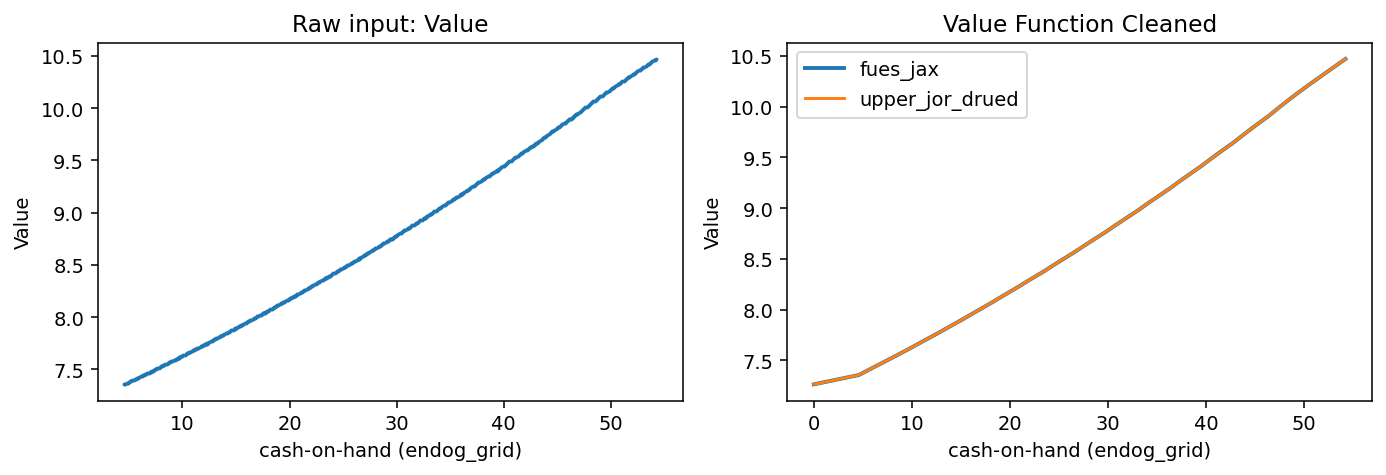

In [20]:
# Plot uncleaned raw correspondence
fig, ax = plt.subplots(1, 2, figsize=(10, 3.5))
ax[0].plot(endog_grid_raw, value_raw, ".", ms=2)
ax[0].set_title("Raw input: Value")
ax[0].set_xlabel("cash-on-hand (endog_grid)")
ax[0].set_ylabel("Value")

# Plot cleaned values
ax[1].plot(ref_m, ref_v, label="fues_jax", lw=2)
ax[1].plot(endog_out, value_out, label="upper_jorg_drued", lw=1.5)
ax[1].set_title("Value Function Cleaned")
ax[1].set_xlabel("cash-on-hand (endog_grid)")
ax[1].set_ylabel("Value")
ax[1].legend()
plt.tight_layout()
plt.show()

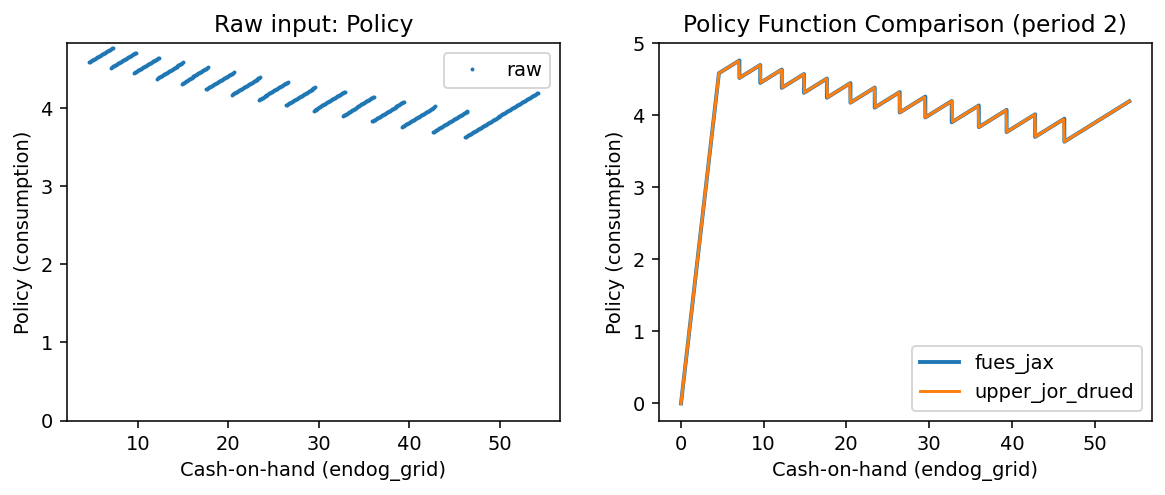

In [25]:
fig, ax = plt.subplots(1, 2, figsize=(10, 3.5))

ax[0].plot(endog_grid_raw, policy_raw, ".", ms=2, label="raw")
ax[0].set_title("Raw input: Policy")
ax[0].set_xlabel("Cash-on-hand (endog_grid)")
ax[0].set_ylabel("Policy (consumption)")
ax[0].legend()
ax[0].set_ylim(bottom=0)

# Plot policy comparison
ax[1].plot(ref_m, ref_c, label="fues_jax", lw=2)
ax[1].plot(endog_out, policy_out, label="upper_jorg_drued", lw=1.5)
ax[1].set_title("Policy Function Comparison (period 2)")
ax[1].set_xlabel("Cash-on-hand (endog_grid)")
ax[1].set_ylabel("Policy (consumption)")
ax[1].legend()

## Zoom around intersections:

`fues_jax` represents an intersection by duplicating an `m` grid point (same x-value appears twice, with different left/right policy values). 
The zoomed plots focus on one such duplicated-`m` location.

zooming around intersection at m = 7.061875924198789


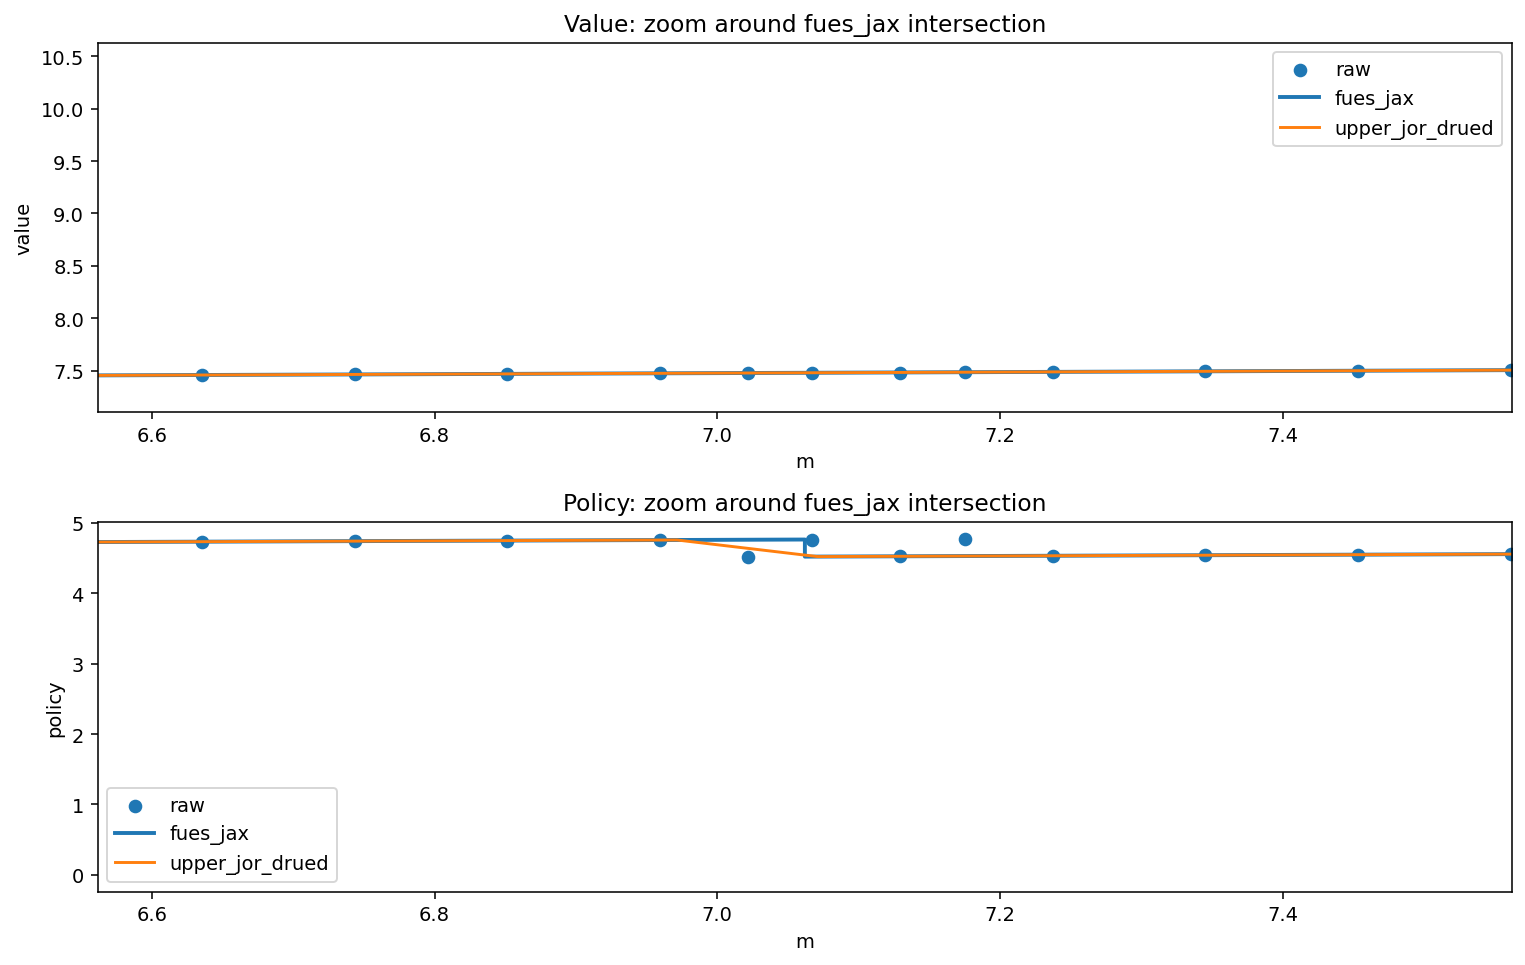

In [18]:
# Identify an intersection location in fues_jax output (duplicate m values)
dup_idx = np.where(np.diff(ref_m) == 0)[0]
m_int = ref_m[dup_idx[0]]
print("zooming around intersection at m =", m_int)

fig, ax = plt.subplots(2, figsize=(11, 7), sharex=False)

# Zoom window around intersection
zoom_half_width = 0.5  # adjust if you want tighter/looser zoom
zx0, zx1 = m_int - zoom_half_width, m_int + zoom_half_width

# Value: zoom
ax[0].scatter(endog_grid_raw, value_raw, label="raw")
ax[0].plot(ref_m, ref_v, lw=2, label="fues_jax")
ax[0].plot(endog_out, value_out, lw=1.5, label="upper_jorg_drued")
ax[0].set_xlim(zx0, zx1)
ax[0].set_title("Value: zoom around fues_jax intersection")
ax[0].set_xlabel("m")
ax[0].set_ylabel("value")

# Policy: zoom
ax[1].scatter(endog_grid_raw, policy_raw, label="raw")
ax[1].plot(ref_m, ref_c, lw=2, label="fues_jax")
ax[1].plot(endog_out, policy_out, lw=1.5, label="upper_jorg_drued")
ax[1].set_xlim(zx0, zx1)
ax[1].set_title("Policy: zoom around fues_jax intersection")
ax[1].set_xlabel("m")
ax[1].set_ylabel("policy")

ax[0].legend()
ax[1].legend()
plt.tight_layout()